In [14]:
import json, re
from pathlib import Path
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ── MACROS ────────────────────────────────────────────────────────────────────
DIR_ORIG    = Path("/data/energy-system-preprocessing/models")
DIR_COMPARE = Path("/data/energy-system-preprocessing/presolve/papilo")
# ─────────────────────────────────────────────────────────────────────────────

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

LABEL = DIR_COMPARE.name

KIND_ORDER  = ["Trivial", "Fast", "Medium", "Exhaustive", "Final"]
kind_colors = {k: cm.get_cmap("tab10", len(KIND_ORDER))(i) for i, k in enumerate(KIND_ORDER)}


def parse_name(stem):
    m = re.match(r"r(\d+)_res(\d+)_f([\d.]+)_t([\d.]+)", stem)
    return {"model": stem, "k": int(m.group(1)), "res": int(m.group(2)),
            "f": float(m.group(3)), "t": float(m.group(4))}


def load_dir(root: Path) -> pd.DataFrame:
    rows = []
    for path in sorted(root.glob("*/metadata.json")):
        stem = path.parent.name
        if not re.match(r"r\d+_res\d+", stem):
            continue
        d   = json.loads(path.read_text())
        p   = d.get("papilo", {})
        tot = p.get("total", {})
        rows.append({
            **parse_name(stem),
            "n_vars":        d.get("n_vars", 0),
            "n_constraints": d.get("n_constraints", 0),
            "nnz":           d.get("nnz", 0),
            "del_cols":      tot.get("del_cols",      0),
            "del_rows":      tot.get("del_rows",      0),
            "chg_bounds":    tot.get("chg_bounds",    0),
            "chg_sides":     tot.get("chg_sides",     0),
            "chg_coeffs":    tot.get("chg_coeffs",    0),
            "tsx_applied":   tot.get("tsx_applied",   0),
            "tsx_conflicts": tot.get("tsx_conflicts", 0),
            "presolver_sequence": p.get("presolver_sequence", []),
            "rounds":             p.get("rounds", []),
        })
    return pd.DataFrame(rows)


df_orig    = load_dir(DIR_ORIG)
df_compare = load_dir(DIR_COMPARE)

# Join: orig provides original dimensions; compare provides presolve reductions.
# Inner join — only models present in both directories are plotted.
df = df_orig[["model", "k", "res", "f", "t", "n_vars", "n_constraints", "nnz"]].merge(
    df_compare[["model", "del_cols", "del_rows", "chg_bounds", "chg_sides", "chg_coeffs",
                "tsx_applied", "tsx_conflicts", "presolver_sequence", "rounds"]],
    on="model", how="inner",
)

df["del_vars_frac"]   = df["del_cols"]      / df["n_vars"]        .where(df["n_vars"]        > 0, np.nan)
df["del_rows_frac"]   = df["del_rows"]      / df["n_constraints"] .where(df["n_constraints"] > 0, np.nan)
df["chg_bounds_frac"] = df["chg_bounds"]    / df["n_vars"]        .where(df["n_vars"]        > 0, np.nan)
df["chg_coeffs_frac"] = df["chg_coeffs"]    / df["nnz"]           .where(df["nnz"]           > 0, np.nan)
df["conflict_ratio"]  = df["tsx_conflicts"] / df["tsx_applied"]   .where(df["tsx_applied"]   > 0, np.nan)
df = df.fillna(0)

PRESOLVERS = sorted({p for seq in df["presolver_sequence"] for p in seq})
seq_cols   = [f"seq_{ps}" for ps in PRESOLVERS]
for ps in PRESOLVERS:
    df[f"seq_{ps}"] = df["presolver_sequence"].apply(lambda s, ps=ps: Counter(s).get(ps, 0))

ps_colors = {ps: cm.get_cmap("tab20", max(len(PRESOLVERS), 1))(i) for i, ps in enumerate(PRESOLVERS)}

ks   = sorted(df["k"].unique())
ress = sorted(df["res"].unique())
k_colors = {k: cm.get_cmap("tab10", len(ks))(i)  for i, k in enumerate(ks)}
r_colors = {r: cm.get_cmap("Set2",  len(ress))(i) for i, r in enumerate(ress)}

size_bins   = [0, 1e3, 1e4, 1e5, 1e6, np.inf]
size_labels = ["<1k", "1k-10k", "10k-100k", "100k-1M", ">1M"]
df["size_bin"] = pd.cut(df["n_vars"], bins=size_bins, labels=size_labels)

print(f"Orig    : {len(df_orig):4d} models  ({DIR_ORIG})")
print(f"Compare : {len(df_compare):4d} models  ({DIR_COMPARE})")
print(f"Joined  : {len(df):4d} models")
print(f"k={ks}  |  res={ress}")
print(f"Presolvers: {PRESOLVERS}")
df[["k", "res", "f", "t", "n_vars", "del_vars_frac", "del_rows_frac", "conflict_ratio"]].head()

Orig    :  440 models  (/data/energy-system-preprocessing/models)
Compare :  440 models  (/data/energy-system-preprocessing/presolve/papilo)
Joined  :  440 models
k=[np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(9), np.int64(10), np.int64(11), np.int64(13), np.int64(15), np.int64(16), np.int64(17), np.int64(20), np.int64(22), np.int64(23), np.int64(25), np.int64(27), np.int64(29), np.int64(30), np.int64(32), np.int64(34), np.int64(35)]  |  res=[np.int64(1), np.int64(8), np.int64(24), np.int64(168)]
Presolvers: ['domcol', 'doubletoneq', 'dualfix', 'propagation', 'stuffing', 'substitution']


/tmp/ipykernel_2172245/1865646553.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  kind_colors = {k: cm.get_cmap("tab10", len(KIND_ORDER))(i) for i, k in enumerate(KIND_ORDER)}
/tmp/ipykernel_2172245/1865646553.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  ps_colors = {ps: cm.get_cmap("tab20", max(len(PRESOLVERS), 1))(i) for i, ps in enumerate(PRESOLVERS)}
/tmp/ipykernel_2172245/1865646553.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  k_colors 

,k,res,f,t,n_vars,del_vars_frac,del_rows_frac,conflict_ratio
0,10,168,0.00,0.0192,213,0.098592,0.277027,0.088106
1,10,168,0.00,0.0833,637,0.843014,0.906015,0.035191
2,10,168,0.00,1.0000,5725,0.814847,0.896887,0.030295
3,10,168,0.25,0.5000,1591,0.824010,0.899713,0.031296
4,10,168,0.50,1.0000,2969,0.818121,0.897882,0.030631


## 1 · Elimination fraction heatmaps (k × res)
Fraction of variables / constraints completely removed, averaged over `f` / `t` variants.

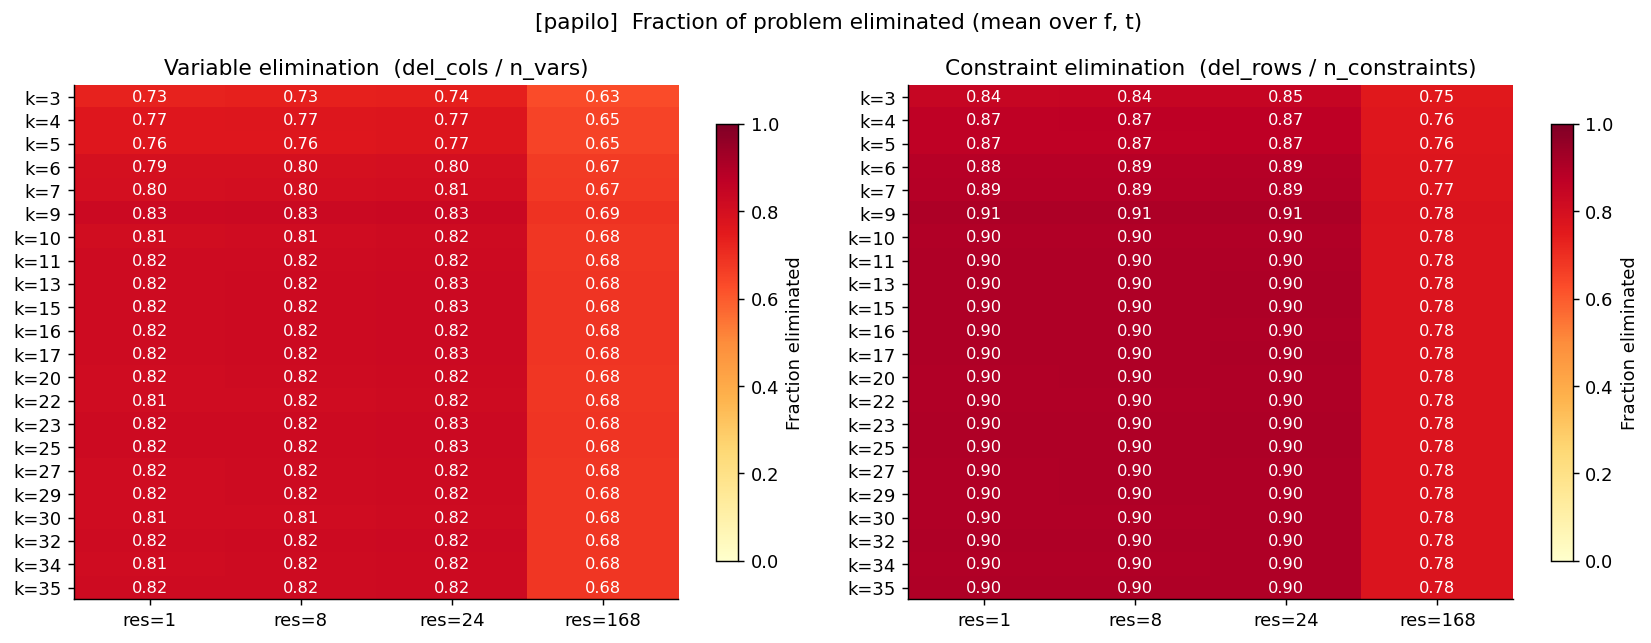

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in [
    (axes[0], "del_vars_frac", "Variable elimination  (del_cols / n_vars)"),
    (axes[1], "del_rows_frac", "Constraint elimination  (del_rows / n_constraints)"),
]:
    pivot = df.groupby(["k", "res"])[col].mean().unstack("res")
    im = ax.imshow(pivot.values, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"res={r}" for r in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"k={k}" for k in pivot.index])
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.values[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                    color="white" if v > 0.6 else "black")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.85, label="Fraction eliminated")

fig.suptitle(f"[{LABEL}]  Fraction of problem eliminated (mean over f, t)", fontsize=12)
fig.tight_layout()
plt.show()

## 2 · Elimination fraction vs k, by resolution
Solid line = mean over `f` / `t`; shaded band = ±1 std.

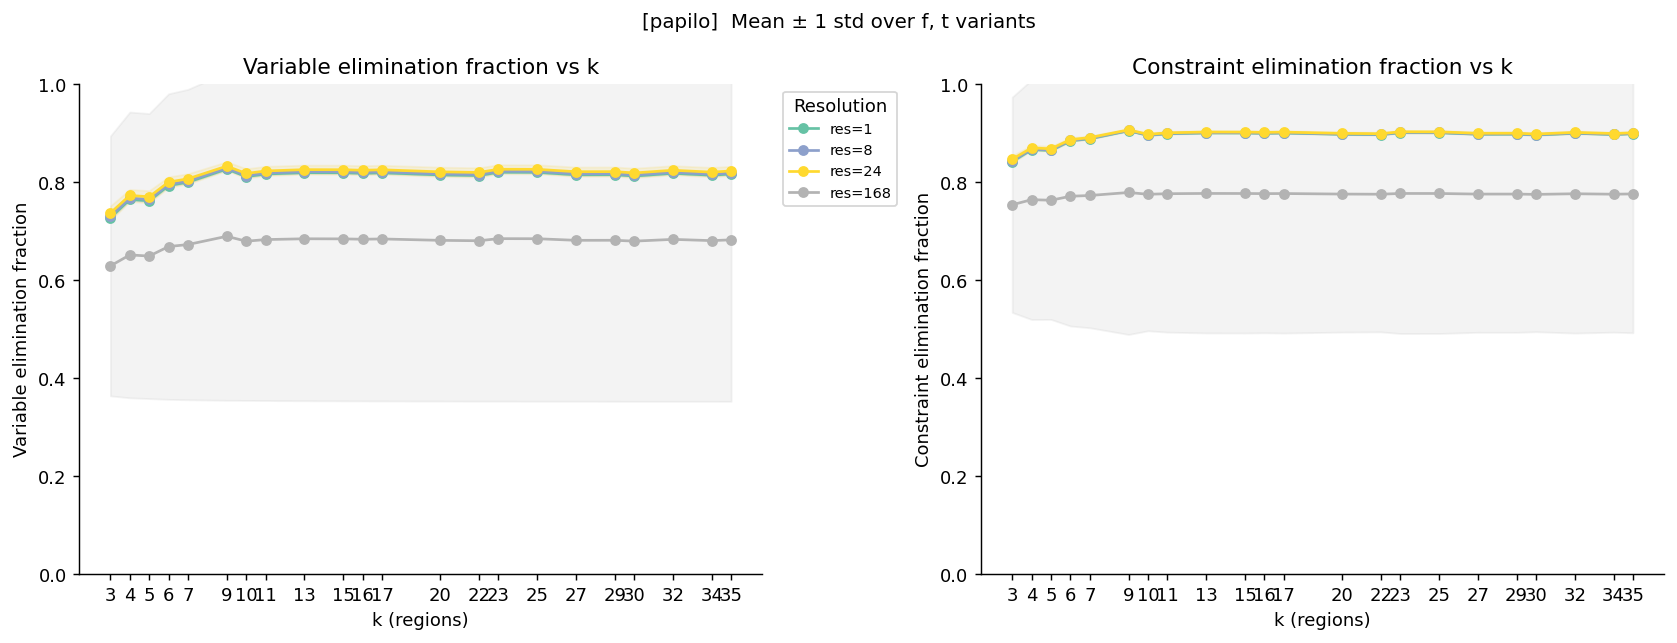

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, label in [
    (axes[0], "del_vars_frac", "Variable elimination fraction"),
    (axes[1], "del_rows_frac", "Constraint elimination fraction"),
]:
    for res in ress:
        grp   = df[df["res"] == res].groupby("k")[col]
        means = grp.mean().reindex(ks)
        stds  = grp.std().reindex(ks)
        ax.plot(means.index, means.values, color=r_colors[res],
                marker="o", markersize=5, label=f"res={res}")
        ax.fill_between(means.index, means - stds, means + stds,
                        color=r_colors[res], alpha=0.15)
    ax.set_xlabel("k (regions)")
    ax.set_ylabel(label)
    ax.set_title(label + " vs k")
    ax.set_xticks(ks)
    ax.set_ylim(0, 1)

axes[0].legend(title="Resolution", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.suptitle(f"[{LABEL}]  Mean ± 1 std over f, t variants", fontsize=11)
fig.tight_layout()
plt.show()

## 3 · Presolve reductions by number of regions (k)
Full distribution across all `res`, `f`, `t` combinations.

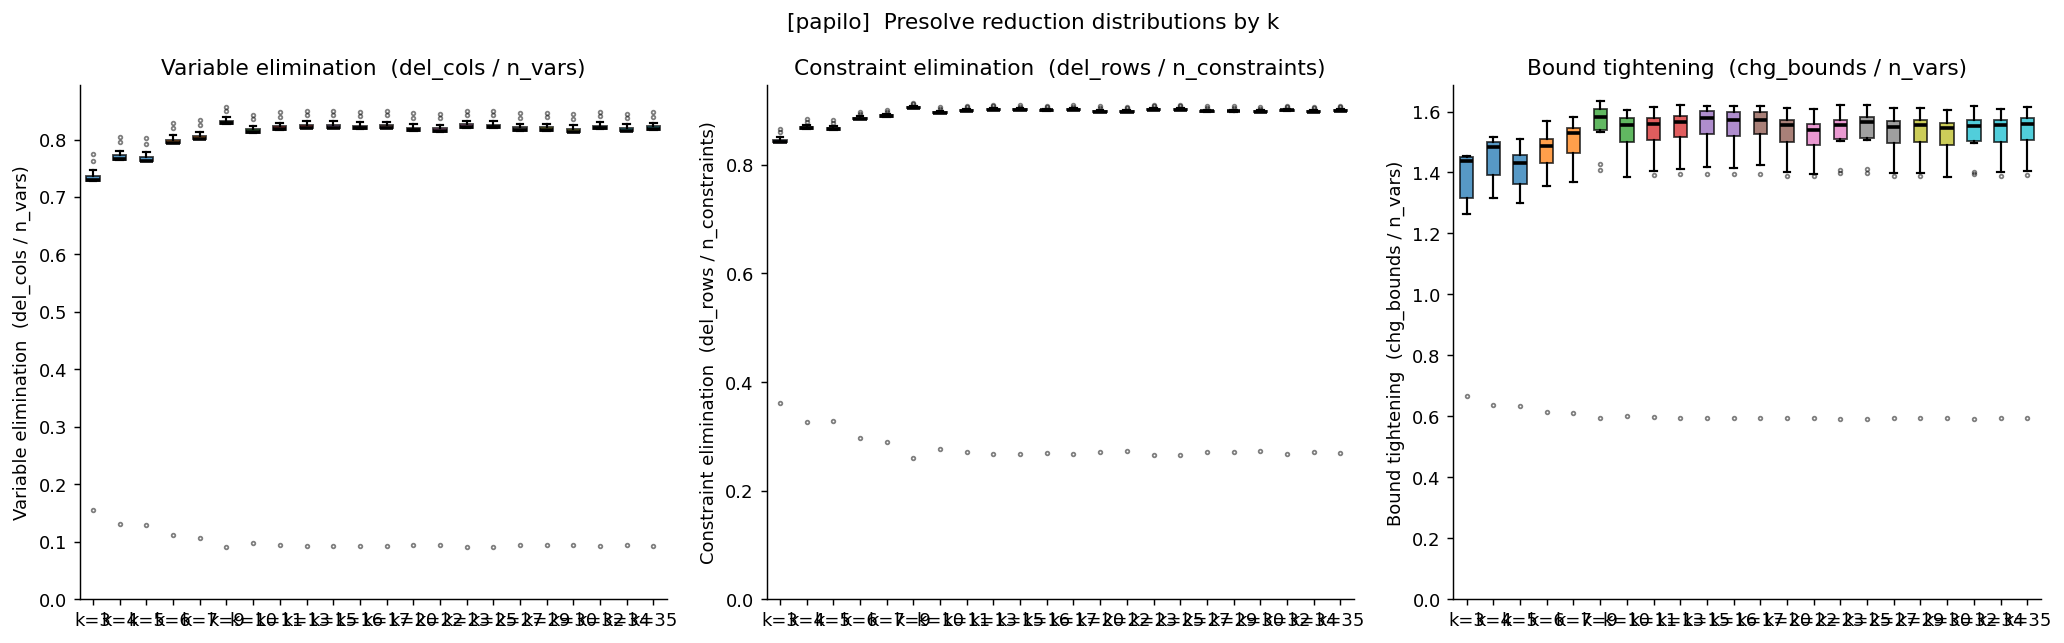

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

panels = [
    ("del_vars_frac",   "Variable elimination  (del_cols / n_vars)"),
    ("del_rows_frac",   "Constraint elimination  (del_rows / n_constraints)"),
    ("chg_bounds_frac", "Bound tightening  (chg_bounds / n_vars)"),
]

for ax, (col, label) in zip(axes, panels):
    data_by_k = [df[df["k"] == k][col].values for k in ks]
    bp = ax.boxplot(data_by_k, patch_artist=True,
                    medianprops=dict(color="black", lw=2),
                    whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
                    flierprops=dict(marker=".", markersize=4, alpha=0.5))
    for patch, k in zip(bp["boxes"], ks):
        patch.set_facecolor(k_colors[k])
        patch.set_alpha(0.75)
    ax.set_xticks(range(1, len(ks) + 1))
    ax.set_xticklabels([f"k={k}" for k in ks])
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_ylim(0, None)

fig.suptitle(f"[{LABEL}]  Presolve reduction distributions by k", fontsize=12)
fig.tight_layout()
plt.show()

## 4 · Variable vs constraint elimination (paired scatter)
Each point is one model. Diagonal = symmetric reduction; above → more rows removed than columns.

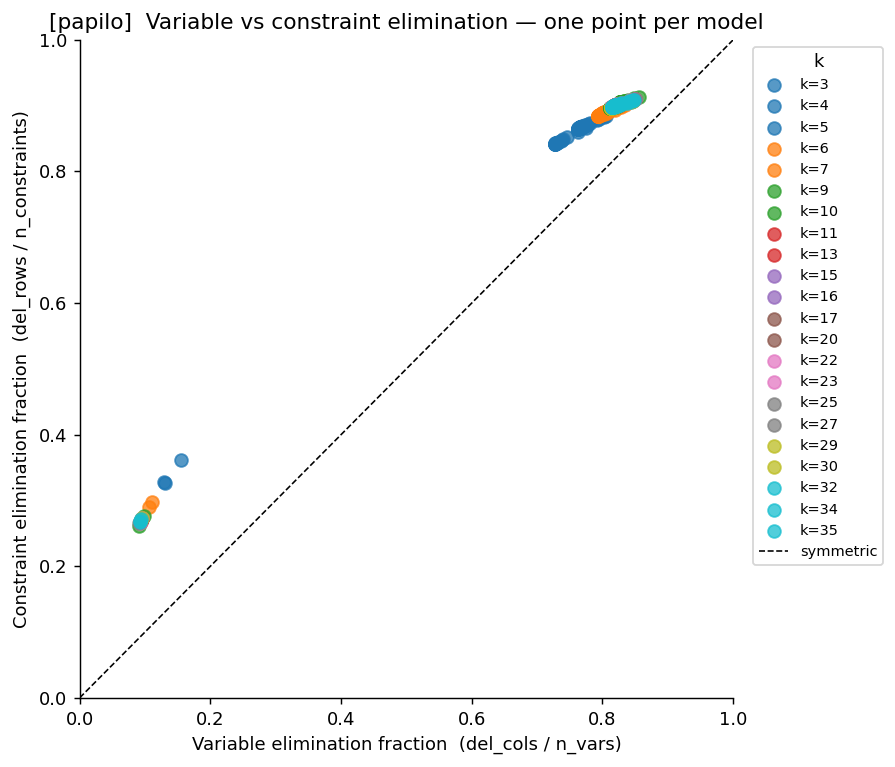

In [18]:
fig, ax = plt.subplots(figsize=(7, 6))

for k in ks:
    sub = df[df["k"] == k]
    ax.scatter(sub["del_vars_frac"], sub["del_rows_frac"],
               color=k_colors[k], label=f"k={k}", alpha=0.75, s=50, zorder=3)

ax.plot([0, 1], [0, 1], "k--", lw=0.9, label="symmetric")
ax.set_xlabel("Variable elimination fraction  (del_cols / n_vars)")
ax.set_ylabel("Constraint elimination fraction  (del_rows / n_constraints)")
ax.set_title(f"[{LABEL}]  Variable vs constraint elimination — one point per model")
ax.legend(title="k", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
fig.tight_layout()
plt.show()

## 5 · Soft presolving actions — bound tightening and coefficient changes
No deletions; these actions tighten the model in place.

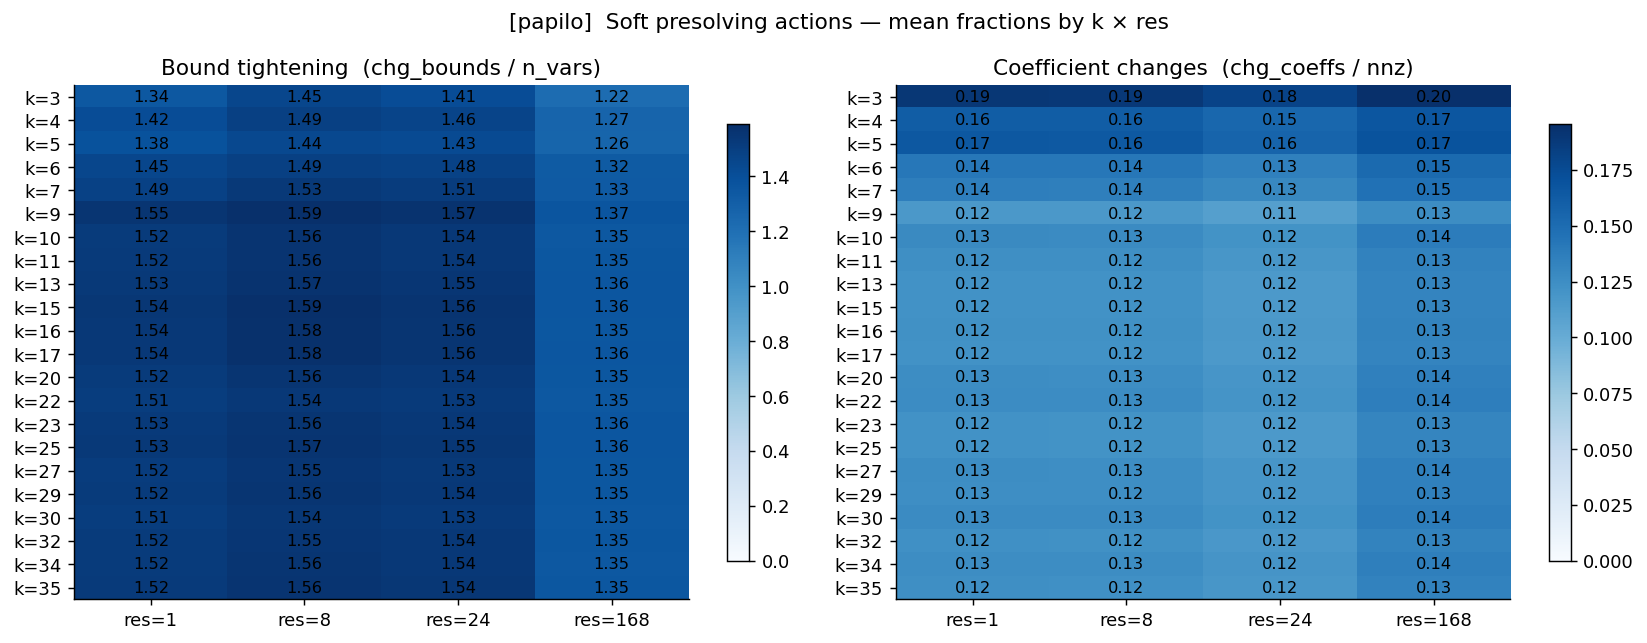

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in [
    (axes[0], "chg_bounds_frac", "Bound tightening  (chg_bounds / n_vars)"),
    (axes[1], "chg_coeffs_frac", "Coefficient changes  (chg_coeffs / nnz)"),
]:
    pivot = df.groupby(["k", "res"])[col].mean().unstack("res")
    vmax  = max(float(pivot.values.max()), 1e-9)
    im = ax.imshow(pivot.values, cmap="Blues", vmin=0, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([f"res={r}" for r in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"k={k}" for k in pivot.index])
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, f"{pivot.values[i, j]:.2f}",
                    ha="center", va="center", fontsize=9)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.85)

fig.suptitle(f"[{LABEL}]  Soft presolving actions — mean fractions by k × res", fontsize=12)
fig.tight_layout()
plt.show()

## 6 · Conflict ratio heatmap  (tsx_conflicts / tsx_applied)
Higher values = more transformations rolled back — signals which model types resist presolving.

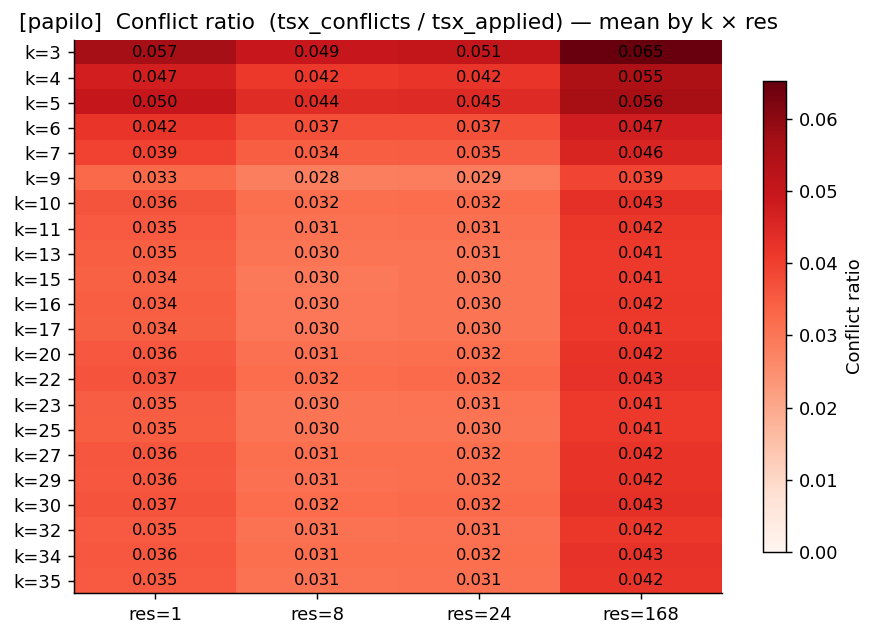

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))

pivot = df.groupby(["k", "res"])["conflict_ratio"].mean().unstack("res")
vmax  = max(float(pivot.values.max()), 1e-9)
im = ax.imshow(pivot.values, cmap="Reds", vmin=0, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"res={r}" for r in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"k={k}" for k in pivot.index])
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i, j]:.3f}",
                ha="center", va="center", fontsize=9)
ax.set_title(f"[{LABEL}]  Conflict ratio  (tsx_conflicts / tsx_applied) — mean by k × res")
plt.colorbar(im, ax=ax, shrink=0.85, label="Conflict ratio")
fig.tight_layout()
plt.show()

## 7 · Round-by-round cumulative reduction
Mean cumulative elimination fraction across all models; segment colour = dominant round kind at that step.

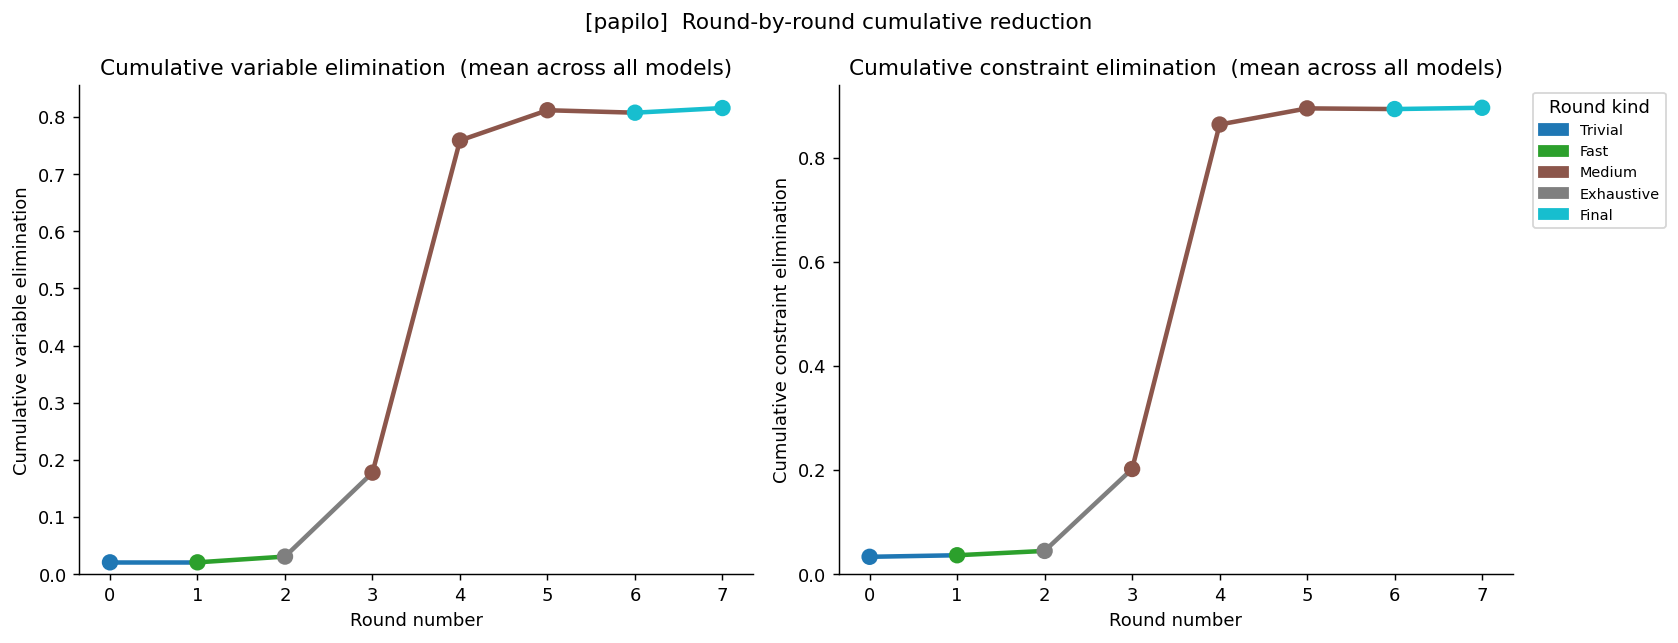

In [21]:
cum_rows = []
for _, row in df.iterrows():
    cum_c, cum_r = 0, 0
    for r in sorted(row["rounds"], key=lambda r: r["number"]):
        cum_c += r["delta"]["del_cols"]
        cum_r += r["delta"]["del_rows"]
        cum_rows.append({
            "round_num": r["number"],
            "kind": r["kind"],
            "cum_del_vars_frac": cum_c / row["n_vars"]        if row["n_vars"]        else 0,
            "cum_del_rows_frac": cum_r / row["n_constraints"] if row["n_constraints"] else 0,
        })

rdf = pd.DataFrame(cum_rows)
mean_by_rnd = rdf.groupby("round_num")[["cum_del_vars_frac", "cum_del_rows_frac"]].mean()
modal_kind  = rdf.groupby("round_num")["kind"].agg(lambda x: x.mode()[0])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, label in [
    (axes[0], "cum_del_vars_frac", "Cumulative variable elimination"),
    (axes[1], "cum_del_rows_frac", "Cumulative constraint elimination"),
]:
    xs = mean_by_rnd.index.tolist()
    ys = mean_by_rnd[col].tolist()
    for i in range(len(xs) - 1):
        c = kind_colors.get(modal_kind[xs[i]], "grey")
        ax.plot([xs[i], xs[i + 1]], [ys[i], ys[i + 1]], color=c, lw=2.5)
    pt_colors = [kind_colors.get(modal_kind[r], "grey") for r in xs]
    ax.scatter(xs, ys, c=pt_colors, zorder=5, s=65)
    ax.set_xlabel("Round number")
    ax.set_ylabel(label)
    ax.set_title(label + "  (mean across all models)")
    ax.set_xticks(xs)
    ax.set_ylim(0, None)

patches = [mpatches.Patch(color=kind_colors[k], label=k) for k in KIND_ORDER]
axes[1].legend(handles=patches, title="Round kind",
               bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.suptitle(f"[{LABEL}]  Round-by-round cumulative reduction", fontsize=12)
fig.tight_layout()
plt.show()

## 8 · Round-kind share of transformations applied, by k
Shows whether heavy lifting happens in fast passes or exhaustive rounds.

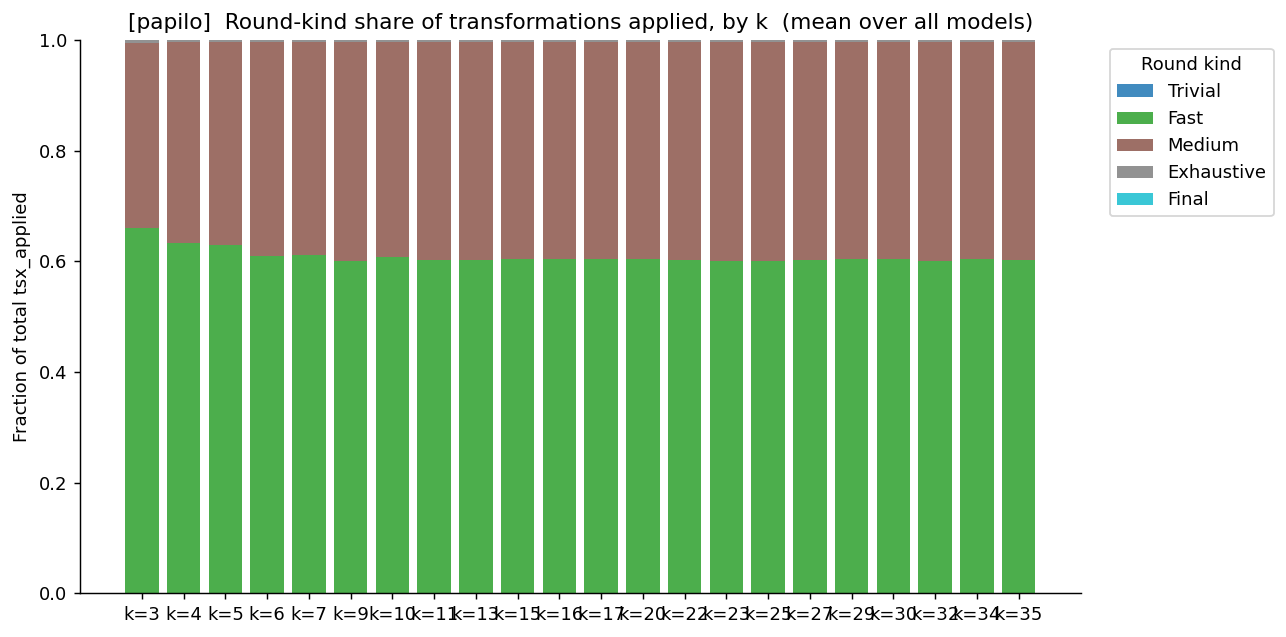

In [22]:
kind_rows = []
for _, row in df.iterrows():
    kind_totals = defaultdict(int)
    for r in row["rounds"]:
        kind_totals[r["kind"]] += r["delta"]["tsx_applied"]
    total = sum(kind_totals.values()) or 1
    kind_rows.append({"k": row["k"],
                      **{kd: kind_totals[kd] / total for kd in KIND_ORDER}})

kdf = pd.DataFrame(kind_rows).groupby("k")[KIND_ORDER].mean()

fig, ax = plt.subplots(figsize=(10, 5))
xs     = np.arange(len(ks))
bottom = np.zeros(len(ks))
for kind in KIND_ORDER:
    vals = kdf.reindex(ks)[kind].fillna(0).values
    ax.bar(xs, vals, bottom=bottom, color=kind_colors[kind], label=kind, alpha=0.85)
    bottom += vals

ax.set_xticks(xs)
ax.set_xticklabels([f"k={k}" for k in ks])
ax.set_ylabel("Fraction of total tsx_applied")
ax.set_title(f"[{LABEL}]  Round-kind share of transformations applied, by k  (mean over all models)")
ax.legend(title="Round kind", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_ylim(0, 1)
fig.tight_layout()
plt.show()

## 9 · Problem size vs reduction rate
Do larger models presolve proportionally more or less?

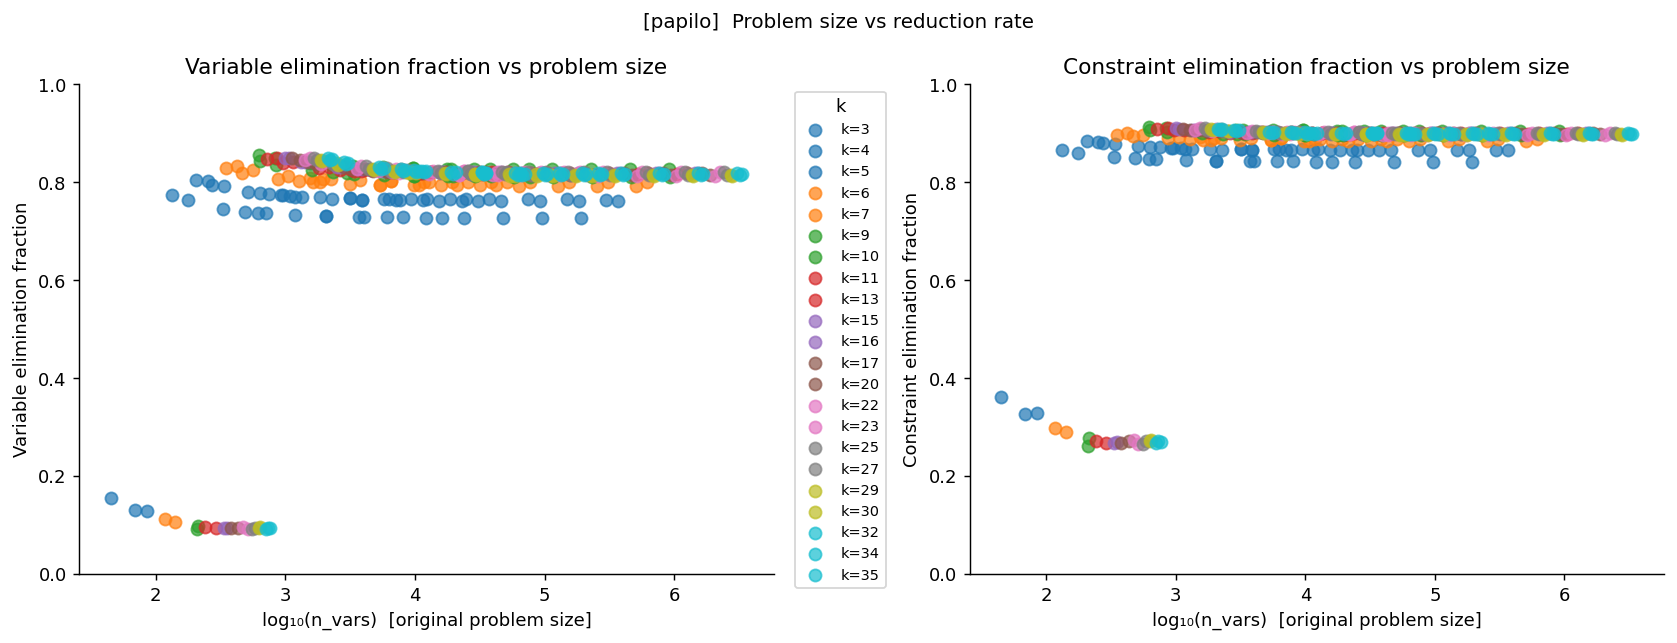

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, label in [
    (axes[0], "del_vars_frac", "Variable elimination fraction"),
    (axes[1], "del_rows_frac", "Constraint elimination fraction"),
]:
    for k in ks:
        sub = df[df["k"] == k]
        ax.scatter(np.log10(sub["n_vars"]), sub[col],
                   color=k_colors[k], label=f"k={k}", alpha=0.7, s=45, zorder=3)
    ax.set_xlabel("log₁₀(n_vars)  [original problem size]")
    ax.set_ylabel(label)
    ax.set_title(label + " vs problem size")
    ax.set_ylim(0, 1)

axes[0].legend(title="k", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.suptitle(f"[{LABEL}]  Problem size vs reduction rate", fontsize=11)
fig.tight_layout()
plt.show()

## 10 · Most commonly used presolvers — by k, resolution, and model size
Stacked bar = mean calls per presolver per model in each group.

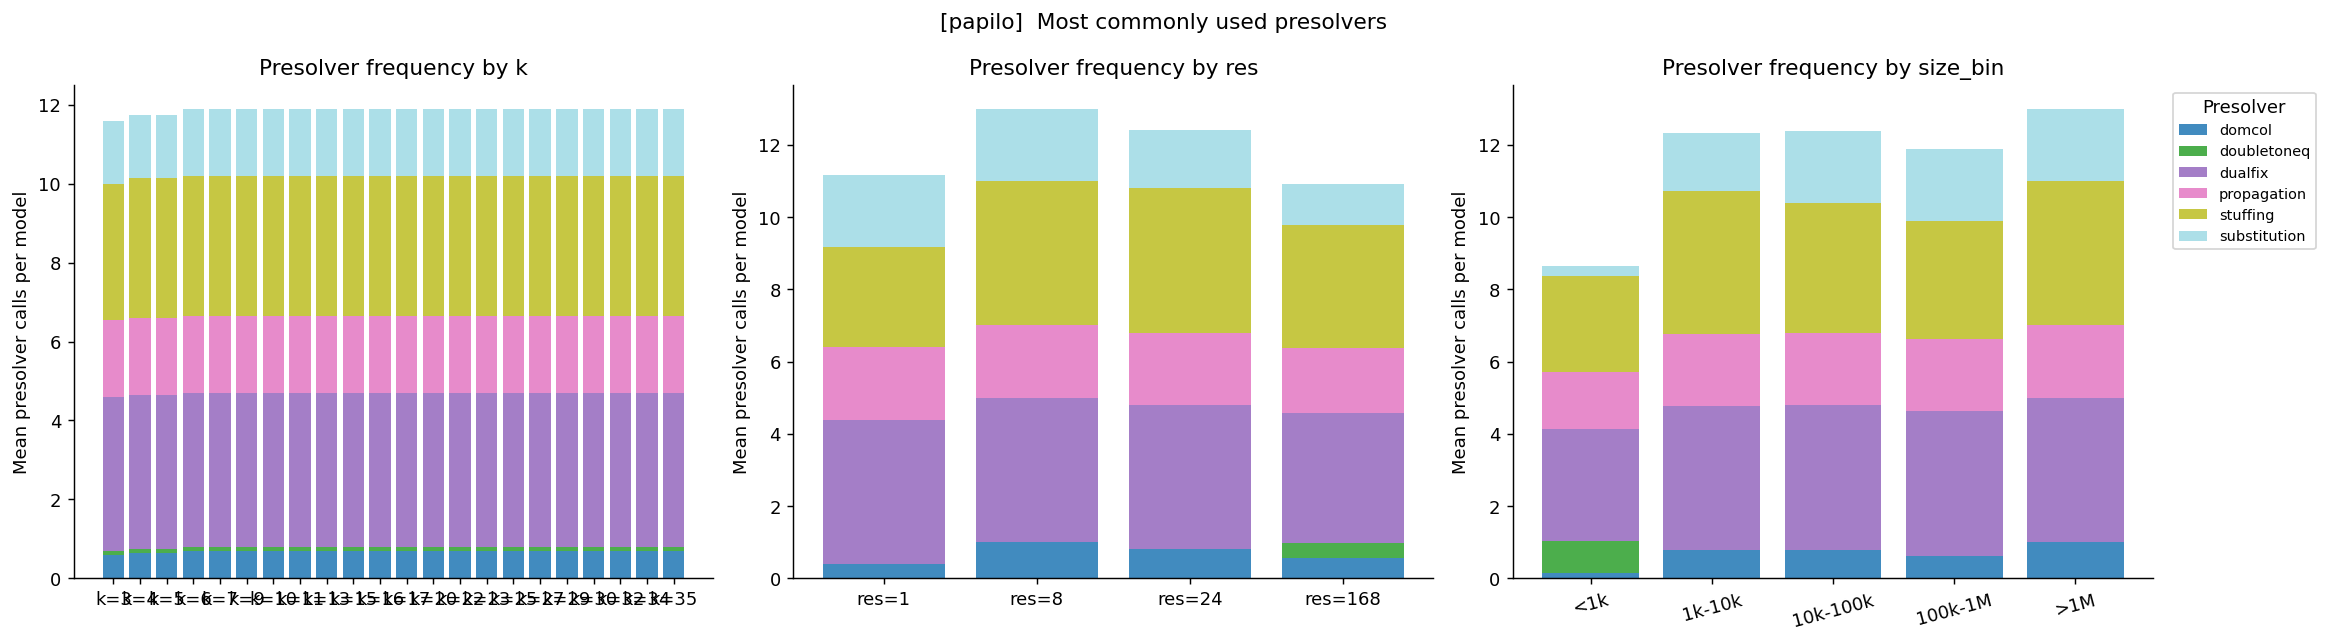

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, grp_col, groups, xlabels in [
    (axes[0], "k",        ks,          [f"k={k}"   for k in ks]),
    (axes[1], "res",      ress,        [f"res={r}" for r in ress]),
    (axes[2], "size_bin", size_labels, size_labels),
]:
    if grp_col == "size_bin":
        agg = df.groupby(grp_col, observed=True)[seq_cols].mean().reindex(size_labels)
    else:
        agg = df.groupby(grp_col)[seq_cols].mean().reindex(groups)
    xs     = np.arange(len(xlabels))
    bottom = np.zeros(len(xlabels))
    for ps in PRESOLVERS:
        vals = agg[f"seq_{ps}"].fillna(0).values
        ax.bar(xs, vals, bottom=bottom, color=ps_colors[ps], label=ps, alpha=0.85)
        bottom += vals
    ax.set_xticks(xs)
    ax.set_xticklabels(xlabels, rotation=15 if grp_col == "size_bin" else 0)
    ax.set_ylabel("Mean presolver calls per model")
    ax.set_title(f"Presolver frequency by {grp_col}")

axes[2].legend(title="Presolver", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.suptitle(f"[{LABEL}]  Most commonly used presolvers", fontsize=12)
fig.tight_layout()
plt.show()

## 11 · Presolver call heatmaps — presolver × k and presolver × resolution
Mean calls per model; reveals which presolvers dominate for each model class.

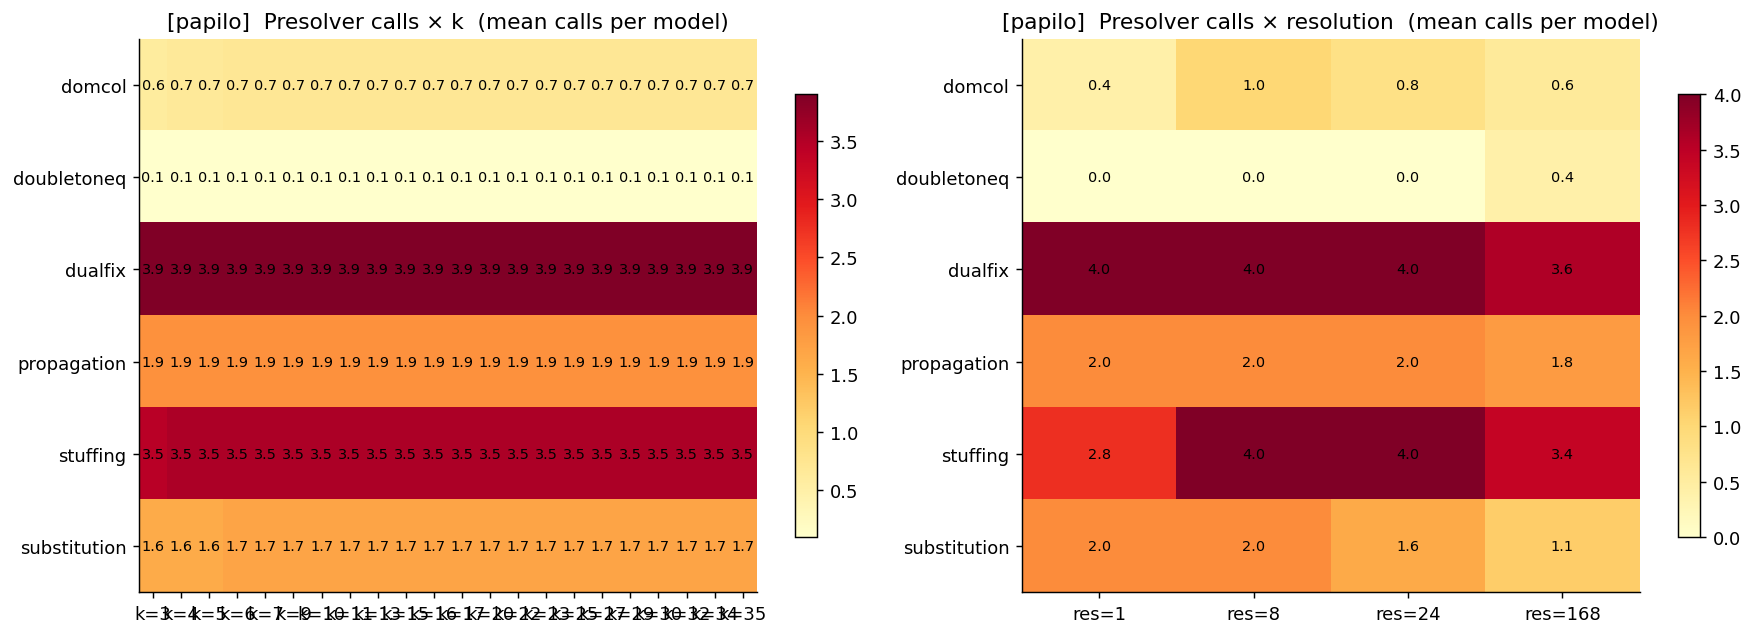

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, grp_col, groups, xlabels, title in [
    (axes[0], "k",   ks,   [f"k={k}"   for k in ks],   "Presolver calls × k"),
    (axes[1], "res", ress, [f"res={r}" for r in ress], "Presolver calls × resolution"),
]:
    matrix = np.array([
        [df[df[grp_col] == g][f"seq_{ps}"].mean() for g in groups]
        for ps in PRESOLVERS
    ])
    im = ax.imshow(matrix, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(xlabels)
    ax.set_yticks(range(len(PRESOLVERS)))
    ax.set_yticklabels(PRESOLVERS)
    for i in range(len(PRESOLVERS)):
        for j in range(len(groups)):
            ax.text(j, i, f"{matrix[i, j]:.1f}",
                    ha="center", va="center", fontsize=8)
    ax.set_title(f"[{LABEL}]  {title}  (mean calls per model)")
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.tight_layout()
plt.show()